# <img style="float: left; padding-right: 20px; height: 70px" src="https://i.imgur.com/cMzxwTN.jpg"> Fundamentos de Machine Learning
## Actividad II, Bagging


<h4>

**Universidad Privada Boliviana**<br/>
**Diplomado en Machine Learning y Ciencia de Datos**<br/>

<h4>

<div style="line-height: 1.5">

### ■ La Solución a la Varianza: Bagging (Bootstrap Aggregating)

En la actividad anterior comprobamos que un Árbol de Decisión individual es demasiado sensible a los datos de entrenamiento (Alta Varianza). Para solucionar esto, la estadística propone una técnica de ensamblaje ("Ensemble") llamada **Bagging**. 

Su premisa es sencilla pero matemáticamente brillante: en lugar de confiar en un solo experto inestable, creamos un **"Comité" de decenas de expertos**, les entregamos a cada uno una muestra ligeramente distinta de los datos (mediante muestreo con reemplazo o *Bootstrapping*), y luego promediamos sus respuestas (o aplicamos voto mayoritario).

#### Celda 1: Comprobación Visual de la Estabilidad
Para observar este efecto curativo, entrenaremos progresivamente ensambles más grandes (desde 1 hasta 60 árboles) y graficaremos cómo la exactitud deja de fluctuar violentamente y se convierte en una línea estable y superior.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Cargar datos y separar X e y
df = pd.read_csv('glass.csv')
X = df.drop('Type', axis=1)
y = df['Type']

# Aislar un Test Set INAMOVIBLE para evaluar a todos por igual
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


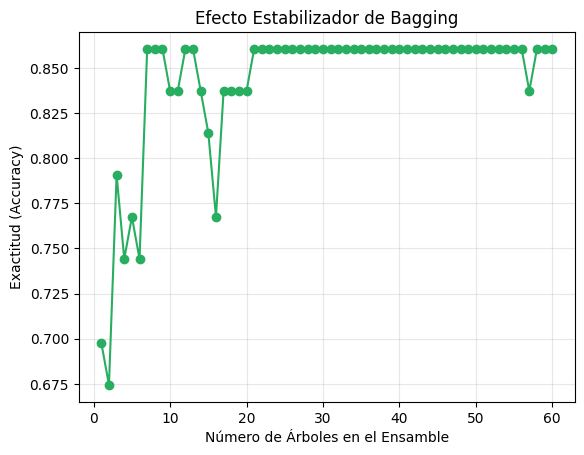

In [2]:

from sklearn.ensemble import BaggingClassifier

lista_estimadores = range(1, 61)
exactitudes_bagging = []

for n in lista_estimadores:
    # Instanciar el ensamble indicando el número de árboles
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        random_state=42, n_jobs=-1
    )
    # Entrenamiento del ensamble
    bagging.fit(X_train_full, y_train_full)
    
    # Guardar el score de este tamaño de comité
    exactitudes_bagging.append(bagging.score(X_test, y_test))

# Código visual sugerido
plt.plot(lista_estimadores, exactitudes_bagging, marker='o', color='#27ae60')
plt.title("Efecto Estabilizador de Bagging")
plt.xlabel("Número de Árboles en el Ensamble")
plt.ylabel("Exactitud (Accuracy)")
plt.grid(True, alpha=0.3)
plt.show()



<div style="line-height: 1.5">

#### Celda 2: La Ventaja Gratuita - Out-of-Bag (OOB) Score

**Magia Estadística:** Como Bagging toma muestras aleatorias con reemplazo para entrenar cada árbol, por pura probabilidad matemática siempre habrá aproximadamente un **36.8% de los datos originales** que un árbol específico *nunca* llegará a ver durante su entrenamiento. A estos datos se les llama **Out-of-Bag (OOB)**.

Podemos usar estos datos "excluidos" para evaluar internamente a cada árbol. Al finalizar, Bagging puede darnos una estimación de su propia exactitud real sin que nosotros tengamos que usar (o si quiera crear) un conjunto `X_test` separado. ¡Es una validación gratuita!



In [3]:

# Instanciamos el ensamble con 100 árboles activando el cálculo OOB
bagging_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    oob_score=True,  # Flag para activar auto-evaluación
    random_state=42
)

bagging_oob.fit(X_train_full, y_train_full)

# Extraemos e imprimimos el atributo matemático calculado internamente
print(f"Exactitud (OOB) interna: {bagging_oob.oob_score_ * 100:.2f}%")
print(f"Exactitud (Test) real:   {bagging_oob.score(X_test, y_test) * 100:.2f}%")


Exactitud (OOB) interna: 70.76%
Exactitud (Test) real:   86.05%


<div style="line-height: 1.5">

#### Celda 3: El Defecto Oculto de Bagging (La Homogeneidad del Nodo Raíz)

Si 100 detectives inician una investigación guiándose siempre por la misma pista obvia, cometerán errores similares y el comité no será realmente "diverso". Puesto que Bagging no restringe la visión de los árboles, estos tienen acceso a **todas** las características en todo momento. 

Demostraremos que casi todos los árboles del ensamble son estructuralmente clones porque seleccionan el mismo mineral dominante como su primera regla de corte (Nodo Raíz).



In [5]:
from collections import Counter

# Accedemos a la lista interna de los 100 árboles generados
indices_raices = []

for arbol in bagging_oob.estimators_:
    # Extraer el índice numérico de la característica usada en el Nodo Raíz
    caracteristica_raiz = arbol.tree_.feature[0]
    indices_raices.append(caracteristica_raiz)

# Mapeamos los índices a sus nombres químicos (Ej: Mg, Al, RI)
nombres_raices = [X.columns[i] for i in indices_raices]

# Contamos las frecuencias
conteo_raices = Counter(nombres_raices)

# Imprimir de forma ordenada
df_raices = pd.DataFrame({
    'Mineral Raíz': list(conteo_raices.keys()),
    'Frecuencia (de 100)': list(conteo_raices.values())
}).sort_values(by='Frecuencia (de 100)', ascending=False)

print(df_raices.to_string(index=False))


Mineral Raíz  Frecuencia (de 100)
          Ba                   47
          Al                   35
          Mg                   15
          Na                    2
           K                    1


<div style="line-height: 1.5">

### El Diagnóstico y el Salto a Random Forest

**Análisis del Experimento de Homogeneidad:** Al ejecutar el código de conteo de raíces, notará que a pesar de existir 9 características químicas, un solo mineral (generalmente el Magnesio - `Mg`) es elegido como raíz en más de 30 árboles. Variables menos comunes nunca tienen la oportunidad de ser exploradas al inicio del árbol.


**Random Forest:**
Para solucionar esta ceguera del comité y forzar a los expertos a buscar otras pistas, la solución es drástica: **Hay que vendarles los ojos**. En el próximo y último notebook implementaremos **Random Forest**, el cual altera el algoritmo base para esconder variables aleatorias en cada división de nodo, obligando a los árboles a ser distintos entre sí y creando, finalmente, un comité verdaderamente diverso y poderoso.


